In [37]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
print(tf.__version__)
def count_connections(input_size, hidden_size, num_hidden_layers, output_size):
    input_to_hidden = input_size * hidden_size
    hidden_to_hidden = hidden_size * hidden_size * (num_hidden_layers - 1)
    hidden_to_output = hidden_size * output_size
    return input_to_hidden + hidden_to_hidden + hidden_to_output

2.18.0


In [38]:
#FIRST MODEL
model1 = tf.keras.Sequential([
    tf.keras.Input(shape = (3,)),   # input layer, shape 3
    tf.keras.layers.Dense(100, activation = "relu"), #hidden layers, 100 neurons per, rectified linear units as activation value, 1MM total
    tf.keras.layers.Dense(100, activation = "relu"),
    tf.keras.layers.Dense(100, activation = "relu"),
    tf.keras.layers.Dense(1, activation = None) #output layer, no activation
])
#compile now
model1.compile(loss = tf.keras.losses.mae, # Loss function
               optimizer = tf.keras.optimizers.SGD(), #Optimizers
               metrics = ["mae"] )
#Fit the model now
#model1.fit(x_train, y_train, epochs = 100)

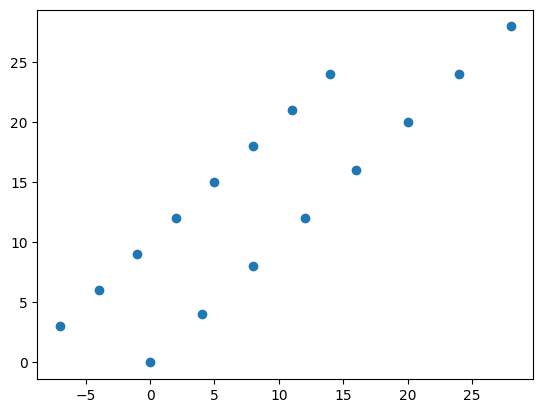

In [39]:
#Write along ; predicting a number based on other numbers; find some data
#features
X = np.array([[ -7.0 , -4.0 , -1.0 , 2.0 , 5.0 , 8.0, 11.0 , 14.0 ,], [0.0 , 4.0 , 8.0 , 12.0 , 16.0 , 20.0 , 24.0 , 28.0 ]])
#labels
y = np.array([[ 3.0 , 6.0 , 9.0 , 12.0 , 15.0 ,18.0 , 21.0 , 24.0 ] ,  [0.0 , 4.0 , 8.0 , 12.0 , 16.0 , 20.0 , 24.0 , 28.0 ]])
plt.scatter(X,y);

In [40]:
y == X + 10

array([[ True,  True,  True,  True,  True,  True,  True,  True],
       [False, False, False, False, False, False, False, False]])

In [41]:
# for our housing price problem, create a demo tensor for it
house_info = tf.constant (["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])
house_info, house_price
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape

((8,), (8,))

In [42]:
#turn nparrays to tensors
X = tf.cast(tf.constant(X), dtype = tf.float32)
y = tf.cast(tf.constant(y), dtype = tf.float32)

1. Creating a model, define the input and output layers, as well as the hidden layers of our deep learning model
2. Compiling a model, define the loss function (in other words, the function which tell our model how wrong it is) and the optimizer (tell our models how to improve the patterns its learning) and evalution metrics (what we can use to interpret the performance of our model).
3. Fitting a model - letting the model try to find patterns between X & y (features and labels)

In [43]:
tf.random.set_seed(42)
#1. create a model using the sequential API

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#2. Compile the model
model.compile(loss = tf.keras.losses.mae, #mean absolute error
              optimizer = tf.keras.optimizers.SGD(), #Stochastic Gradient Descent
              metrics = ["mae"]
              )

#3. Fit the model
model.fit(X, y, epochs = 1) #epochs meaning the number of times the entire training dataset is passed through


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 647ms/step - loss: 7.0000 - mae: 7.0000


In [44]:
#Using the sequential api, you can either pass it a list of all your layers or add them using the add method
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(1))




In [45]:
X, y

(<tf.Tensor: shape=(2, 8), dtype=float32, numpy=
 array([[-7., -4., -1.,  2.,  5.,  8., 11., 14.],
        [ 0.,  4.,  8., 12., 16., 20., 24., 28.]], dtype=float32)>,
 <tf.Tensor: shape=(2, 8), dtype=float32, numpy=
 array([[ 3.,  6.,  9., 12., 15., 18., 21., 24.],
        [ 0.,  4.,  8., 12., 16., 20., 24., 28.]], dtype=float32)>)

To improve a model, you alter the steps that were taken to create the model
1. creating a model, here we might add more layers, increase the number of hidden units, neurons, and we might cahnge the avctivation function of each layer
2. compiling a model, change the optimization function or perhaps the learning rate of the optimization function.
3. fitting a model, might run it through more epochs, or with more data.

In [46]:
#Rebuilding

#Create
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
#Compile
model.compile(loss=tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ["mae"])
#Fit (longer this time)
model.fit(X, y , epochs = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - loss: 7.4548 - mae: 7.4548


In [47]:
#Remind
#Create
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1)
])
#Comppile
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ["mae"])
#Fit
model.fit(X, y, epochs = 1
          )


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step - loss: 14.0913 - mae: 14.0913


Various ways to tweak deep learning models: adding layers, increase the number of hidden units, change the activation functions, change the optimization function, change the learning rate.

In [48]:
X= tf.range(-100 , 100 , 4)

In essence, what tensorflow does is abstract the bulk of the code away from the user and allow them to create models easily. Build, fit, evaluate, repeat is a philsophy that tensorflow allows to occur.


Visualize; what should we?
The data
the model itself
the predictions of the model


In [49]:
y = X + 10


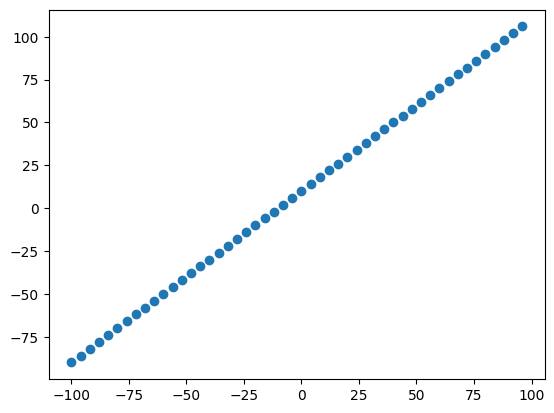

In [50]:
plt.scatter(X,y)

Data is often in three sets:
The training set, this is most of your data, say 70-80%
**Validation set** - the model gets tuned ont his data, tpyically 10-15%
**Test set** - model get evaluated on this data

In [51]:
 ##Evaluting a model si as follows

 '''
 Build a model -> fit it -> evaluate it -> tweak the model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it ETC.......
'''
len(X)

50

In [52]:
X_train = X[:40]
y_train= y[:40]
X_test = X[40:]
y_test = y[40:]
len(X_train), len(X_test) , len(y_train), len(y_test)

(40, 10, 40, 10)

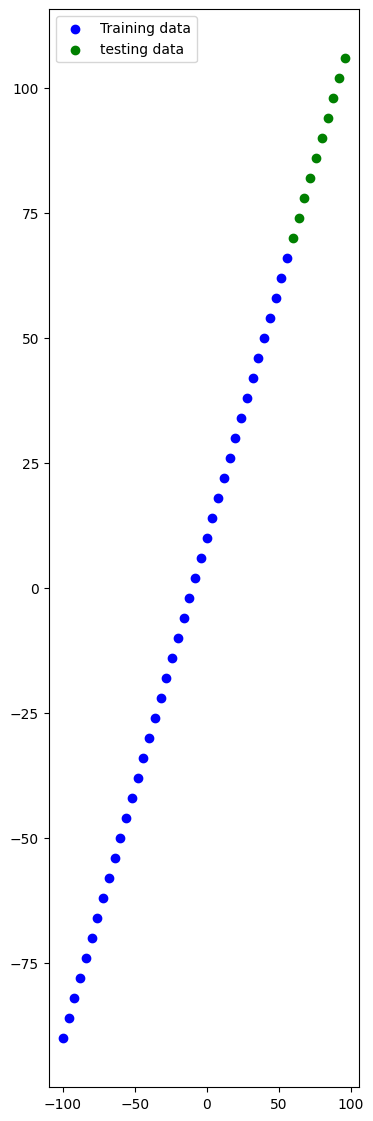

In [53]:
plt.figure(figsize = (4, 14))

plt.scatter(X_train , y_train , c="b" , label = "Training data")
plt.scatter(X_test , y_test , c = "g", label = "testing data" )
plt.legend();

In [54]:
#def model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
#compile model
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ["mae"])
#fit model
#X_train = X_train.reshape(-1,1)
#y_train = y_train.reshape(-1,1)
model.fit(X_train, y_train, epochs = 50)
model.summary()

Epoch 1/50


ValueError: Input 0 of layer "dense_24" is incompatible with the layer: expected min_ndim=2, found ndim=1. Full shape received: (None,)

In [ ]:
model.summary()

Trainable param: these are the parameters (patterns) the model can update as it trains.
Non-trainable params: the difference between the total and the trainable, these are static and are usually pre trained and already have established patterns and relationships.

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1,  input_shape = [1])
])
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ["mae"]
              )

In [ ]:
model.fit(X_train, y_train, epochs = 100, verbose = 0)

In [ ]:
model.summary()

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model=model, show_shapes = True)

In [ ]:
y_pred = model.predict(X_test, verbose = 0)
def plot_predictions( train_data = X_train,
                     train_labels = y_train,
                      test_data = X_test,
                      test_labels = y_test,
                      predictions = y_pred):

    plt.figure(figsize = (4, 14))
    plt.scatter(train_data, train_labels, c = "b", label = "Training data")
    plt.scatter(test_data, test_labels, c = "g", label = "Testing data")
    plt.scatter(test_data, predictions, c = "r", label = "Predictions")
    plt.legend();

In [ ]:
plot_predictions()

In [ ]:
#Evaluation
'''
Common regression evalution methods: MAE ; a great starter metrics for any regression problem, MSE ; Good for when larger errors are more significant than smaller errors, HUBER ; Piecewise combination function of MSE and MAE - less sensitive to outliers than MSE.



'''
model.evaluate(X_test, y_test)

In [ ]:
tf.squeeze(y_pred)
mae = tf.keras.losses.MAE(y_true = y_test,
                                     y_pred = tf.constant(y_pred))
mae

In [ ]:
mae = tf.metrics.MAE(y_true = y_test, y_pred = tf.squeeze(y_pred))
mae

In [ ]:
tf.keras.losses.MSE(y_true = y_test,
                    y_pred = tf.squeeze(y_pred))

In [ ]:
tf.keras.losses.huber(y_true = y_test,
                      y_pred = tf.squeeze(y_pred))

In [ ]:
def mae(y_true, y_pred):
  return tf.metrics.mean_absolute_error(y_true, y_pred)
def mse(y_true, y_pred):
  return tf.metrics.mean_squared_error(y_true, y_pred)
def huber(y_true, y_pred):
  threshold = 1
  error = y_true - y_pred

In [ ]:
###Experimentation : Get more data, make your model larger or complex, train for longer: give your model more of a chance.



In [ ]:
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

model_1.compile(loss = tf.keras.losses.mae,
                optimizer = tf.keras.optimizers.SGD(),
                metrics = ["mae"])
model_1.fit(X_train, y_train, epochs = 1)

In [ ]:
mae_1 = tf.keras.losses.MAE(y_test, y_pred)
mse_1 = tf.keras.losses.MSE(y_test, y_pred)
mae_1 , mse_1

Model_1 : same as the og model, 1 layer, trained for 100 epochs.
Model_2  : 2 layer, train for 100 epochs
Model_3 : 2 layers, train for 100 epochs
Model_4 : 3 layers, train for 100 epochs
Model_5 : 3 layers, train for 500 epochs


In [ ]:
X_train.shape, y_train.shape

In [ ]:
tf.random.set_seed(42)
X_train = tf.expand_dims(X_train, axis = 1)
y_Train = tf.expand_dims(y_train, axis= 1)
#Def model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
#Compile Model
model_1.compile(loss = tf.keras.losses.mae,
                optimizer = tf.keras.optimizers.SGD(),
                metrics = ["mae"])
#Fit the model
model_1.fit(X_train, y_train, epochs = 1)

In [ ]:
X_train = tf.reshape(X_train , shape = (40))
model_2 = tf.keras
X_train.shape, y_train.shape

In [ ]:
y_preds_1 = model_1.predict(X_test)
plot_predictions(predictions = y_preds_1)

In [ ]:
X_train = tf.expand_dims(X_train, axis = 1)
y_train = tf.expand_dims(y_train, axis = 1)
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(10)
])
model_2.compile(loss = tf.keras.losses.mae,
                optimizer = tf.keras.optimizers.SGD(),
                metrics = ["mse"])
model_2.fit(X_train, y_train, epochs = 100)


In [ ]:
y_preds_2 = model_2.predict(X_test)
plot_predictions()

In [ ]:
mae_2 = tf.keras.losses.MAE(y_test, y_pred)
mse_2 = tf.keras.losses.MSE(y_test, y_pred)
mae_2 , mse_2

In [ ]:
tf.random.set_seed(42)
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])
model_3.compile(loss = tf.keras.losses.mae,
                optimizer = tf.keras.optimizers.SGD(),
                metrics = ["mse"])

model_3.fit(X_train, y_train, epochs = 100)

In [ ]:
plot_predictions()

In [ ]:
X_test= tf.reshape(X_test, shape = (10,1,1))
y_preds_3 = model_3.predict(X_test)
plot_predictions()

In [ ]:
mae_3 = tf.keras.losses.MAE(y_test, y_pred)
mse_3 = tf.keras.losses.MSE(y_test, y_pred)
mae_3 , mse_3

Comparing Results
**note:**  start with small models to make sure they work before we increase scale

In [ ]:
model_results = [["model_1", mae_1.numpy(), mse_1.numpy()],
                 ["model_2", mae_2.numpy(), mse_2.numpy()],
                 ["model_3 ", mae_3.numpy(), mse_3.numpy()]]
all_results = pd.DataFrame(model_results, columns = ["model" , "mae" , "mse"])
all_results

In [ ]:
model_3.summary()

##Tracking your experiments
one really good habit in machine learning is to track the results of your experiements and compare
* Tensor board is a componenet of tensorflow that can help track modelling experiments
* Weights & Biases - a tool for tracking all of kinds of machine learning experiements
* Saving our models allow us to use them outside of colab: model.save() , SavedModel format and HDF5 format both are options


In [ ]:
#model_3.save("best_model_ever.keras")
#model_3.save("best_model_ever.h5")

In [ ]:
#loading
SavedModel_format = tf.keras.models.load_model("best_model_ever.keras")
loaded_H5_model = tf.keras.models.load_model("best_model_ever.h5")

In [ ]:
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])


## How to Download a file from google colab.
Go to files and right click to download
* Or use CODEEEE

In [ ]:
from google.colab import files
files.download("best_model_ever.h5")

In [ ]:
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
insurance

In [ ]:
data_onehot = pd.get_dummies(insurance)
data_onehot.head()

In [ ]:
X = data_onehot.drop("charges", axis = 1)
y = data_onehot["charges"]

In [ ]:
X.head()

In [ ]:
y.head()

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
len(X), len(X_train), len(X_test)

In [ ]:
tf.random.set_seed(42)

insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
  ])
insurance_model.compile(loss = tf.keras.losses.mae,
                        optimizer = tf.keras.optimizers.Adam(),
                        metrics = ["mae"])

insurance_model.fit(X_train, y_train, epochs = 100)

In [ ]:
insurance_model.evaluate(X_test, y_test)

In [ ]:
y_train.median(), y_train.mean()
#Our model is off by quite a bit relative to the averages of our data sets. How can we fix this?

In [57]:
tf.random.set_seed(42)
insurance_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(125),
    tf.keras.layers.Dense(25),
    tf.keras.layers.Dense(5),
    tf.keras.layers.Dense(1)
  ])

insurance_model_2.compile(loss = tf.keras.losses.mae,
                          optimizer = tf.keras.optimizers.Adam(),
                          metrics = ["mae"])

#insurance_model_2.fit(X_train, y_train, epochs = 100, verbose = 0) # running this model for 500 epochs only decreases the loss by about 20 when compared with 1-- epochs. Seems to approach 3600

In [ ]:
history = insurance_model_2.fit(X_train, y_train, epochs = 100, verbose = 0)
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")
#BEAUTIFUL GRAPHIC! This model seems to reach a horizontal asymptote at around a loss of 3600.

In [ ]:
#Our new model performed better... by about 25%, however this is still a bit too high of an error relative to the average values of our datasets.
insurance_model_2.evaluate(X_test, y_test)

Preprocessing data (normalization and stadardization)

In [62]:
 import pandas as pd
 import matplotlib.pyplot as plt
 import tensorflow as tf
 import numpy as np

 insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")

In [65]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
#Create a column transformer

ct = make_column_transformer(
    (MinMaxScaler(), ["age", "bmi","children"]),
    (OneHotEncoder(handle_unknown = "ignore"), ["sex", "smoker", "region"])
)
#Establish X and y
X = insurance.drop("charges", axis = 1)
y = insurance["charges"]
#Build the train and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)\
#Fit the column tranformer to our training data with a given model

ct.fit(X_train)

X_train_normal = ct.transform(X_train)
X_test_normal = ct.transform(X_test)

In [61]:
#How does it look now?
X_train_normal[0] , X_train.loc[0]

(array([0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
        1.        , 0.        , 0.        , 1.        , 0.        ,
        0.        ]),
 age                19
 sex            female
 bmi              27.9
 children            0
 smoker            yes
 region      southwest
 Name: 0, dtype: object)

In [35]:
X_train.shape, X_train_normal.shape

((1070, 6), (1070, 11))

In [58]:
tf.random.set_seed(42)
insurance_model_2.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [67]:
tf.random.set_seed(42)

insurance_model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(243),
    tf.keras.layers.Dense(81),
    tf.keras.layers.Dense(27),
    tf.keras.layers.Dense(9),
    tf.keras.layers.Dense(3),
    tf.keras.layers.Dense(1)
])

insurance_model_3.compile(loss = tf.keras.losses.mae,
                          optimizer = tf.keras.optimizers.Adam(),
                          metrics = ["mae"]
)

#insurance_model_3.fit(X_train, y_train, epochs = 100)

In [71]:
tf.random.set_seed(42)

insurance_model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(125),
    tf.keras.layers.Dense(25),
    tf.keras.layers.Dense(5),
    tf.keras.layers.Dense(1),
])

insurance_model_4.compile(loss = tf.keras.losses.mae,
                          optimizer = tf.keras.optimizers.Adam(),
                          metrics = ["mae"]
)

insurance_model_4.fit(X_train_normal, y_train, epochs = 100) #Only nuance from insurance_model_2 is that we trained on normalized data! We can observe that we reach an asymptote around the same 3570 level

In [73]:
insurance_model_4.evaluate(X_test_normal, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3211.9758 - mae: 3211.9758  


[3158.5107421875, 3158.5107421875]

Text(0.5, 0, 'epochs')

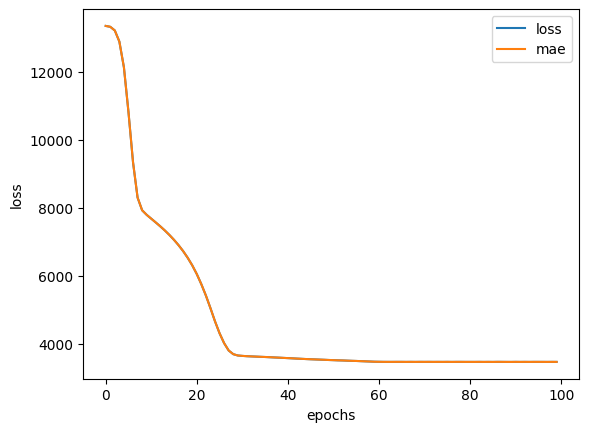

In [72]:
#Plot
history = insurance_model_4.fit(X_train_normal, y_train, epochs = 100, verbose = 0)
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")

Classification problems: Binary, muiltclass, multilabel etc.




For an input into a classification problem, it's shape usually represented as a tensor as follows: [batch_size, width, height, color_channels], so for example
Shape = [32, 224, 224, 3]. This tensor,. or vector, could very well represented an image as an input into a model where as the output Shape coudl = [3], for a multiclass problem where each element represents the probability of a given output being correct.